In [5]:
import os 
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import psycopg2
import pandas as pd

load_dotenv()

HOST = os.getenv("POSTGIS_HOST")
PORT = int(os.getenv("POSTGIS_PORT"))
USER = os.getenv("POSTGIS_USER")
PASSWORD = os.getenv("POSTGIS_PASSWORD")

engine = create_engine(
    f"postgresql://{USER}:{PASSWORD}@{HOST}:{PORT}/incendies",
    connect_args={"options": "-csearch_path=incendies_schema,public"}
)

# Test de connexion
try:
    with engine.connect() as conn:
        result = conn.execute(text("SELECT version()"))
        print("Connexion réussie !")
        print("Version PostgreSQL :", result.scalar())

        dbs = conn.execute(
            text("SELECT datname FROM pg_database WHERE datistemplate = false ORDER BY datname")
        ).fetchall()
        print("Bases de données :", [db[0] for db in dbs])
except Exception as e:
    print("Erreur de connexion :", e)


Connexion réussie !
Version PostgreSQL : PostgreSQL 17.5 (Debian 17.5-1.pgdg110+1) on x86_64-pc-linux-gnu, compiled by gcc (Debian 10.2.1-6) 10.2.1 20210110, 64-bit
Bases de données : ['incendies', 'postgres']


In [6]:
DATABASE_NAME="incendies"

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DATABASE_NAME}",
        connect_args={"options": "-csearch_path=incendies,public"},
    )

engine = get_engine()

## Mise à jour de la table "localisation" pour le type geométrique

In [ ]:
with engine.connect() as conn:
    conn.execute(text("CREATE EXTENSION IF NOT EXISTS postgis"))
    conn.commit()

In [ ]:
# Update de localisation avec les datatype geometry
ddl = [
    """
    ALTER TABLE localisation
      ADD COLUMN IF NOT EXISTS geom geometry(Point, 4326)
        GENERATED ALWAYS AS (
          ST_SetSRID(ST_MakePoint(longitude, latitude), 4326)
        ) STORED
    """,
    """
    ALTER TABLE localisation
      ADD COLUMN IF NOT EXISTS geom_m geometry(Point, 2154)
        GENERATED ALWAYS AS (
          ST_Transform(
            ST_SetSRID(ST_MakePoint(longitude, latitude), 4326),
            2154
          )
        ) STORED
    """,
    """
    CREATE INDEX IF NOT EXISTS localisation_geom_m_gix
      ON localisation USING GIST (geom_m)
    """,
]

with engine.begin() as conn:
    conn.execute(text("SET search_path TO incendies, public"))
    for stmt in ddl:
        conn.execute(text(stmt))
        conn.commit()

In [ ]:
# Récupération
with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            id_localisation,
            ST_X(geom_m) AS x,
            ST_Y(geom_m) AS y
        FROM localisation
        WHERE geom_m IS NOT NULL
    """), conn)

if df.empty:
    raise ValueError("aucun incendie à clusteriser")

### DBSCAN : Type complete

In [ ]:
from sklearn.cluster import DBSCAN
import numpy as np

# min_samples: au moins 4 feux
min_samples = 20

# sklearn attend un tableau NumPy
X = df[["x", "y"]].to_numpy()

db = DBSCAN(eps=2000, min_samples=min_samples)

# fit_predict(X) fait deux choses d’un coup : il apprend les clusters sur X, 
#  puis renvoie un tableau d’entiers, une valeur par ligne, dans le même ordre que df.
#  Dès qu’il trouve un nouveau groupe dense, il lui donne le prochain entier : 0, puis 1, puis 2
#  Il peut renvoyer -1 : point trop isolé
df["cluster_id"] = db.fit_predict(X)

# 0 pour isolé, à partir de 1 pour les clusters
df["cluster_id"] = np.where(df["cluster_id"] == -1, 0, df["cluster_id"] + 1)

,id_localisation,x,y,cluster_id
0,1,8.482493e+05,6.563046e+06,0
1,2,8.874698e+05,6.548128e+06,0
2,3,8.827595e+05,6.542541e+06,0
3,4,8.472752e+05,6.545804e+06,0
4,5,9.021843e+05,6.519819e+06,0
...,...,...,...,...
34925,34926,7.721667e+06,7.525223e+05,0
34926,34927,7.737944e+06,7.438967e+05,0
34927,34928,7.753805e+06,7.638656e+05,0
34928,34929,7.732784e+06,7.412640e+05,0


In [24]:
len(df["cluster_id"].unique())

139

### Mise à jour table cluster

In [6]:
from datetime import date, datetime, timezone

with engine.connect() as conn:
    type_cluster = conn.execute(text("""
        SELECT id
        FROM type_cluster
        WHERE nom = 'complete'
    """)).scalar_one()

# date experiment
df["date_experiment"] = datetime.now()
# type_cluster
df["type_cluster"] = type_cluster

# colonnes de la table cluster
df_insert = df[["id_localisation", "date_experiment", "cluster_id", "type_cluster"]]

sql = text("""
    INSERT INTO cluster (
        id_localisation, cluster_id, type_cluster, date_experiment
    )
    VALUES (
        :id_localisation, :cluster_id, :type_cluster, :date_experiment
    )
""")

with engine.begin() as conn:
    conn.execute(sql, df_insert.to_dict(orient="records"))

In [72]:
# TOTAL COMMUNES
with engine.connect() as conn:
    df_communes = pd.read_sql(text("""
        SELECT 
        l.id_localisation,
            ST_X(l.geom_m) AS x,
            ST_Y(l.geom_m) AS y,
            count(i.code_insee) as nb_incendies,
            sum(Surface_Parcourue) as surface_totale
        FROM localisation l, incendie i, commune c, departement d, region r
        WHERE 
        l.id_localisation = i.localisation
        AND
        i.code_insee = c.code_insee
        AND
        c.departement = d.code
        AND
        c.region = r.id
        AND 
        d.code NOT IN ('971','972','973','974','976')
        AND
        geom_m IS NOT NULL
        GROUP BY l.id_localisation, i.code_insee
    """), conn)

if df_communes.empty:
    raise ValueError("aucun incendie à clusteriser")

print(df_communes[["x", "y"]].describe())

                  x             y
count  9.418000e+03  9.418000e+03
mean   6.901687e+05  6.472142e+06
std    2.205439e+05  2.099280e+05
min    1.289136e+05  6.051804e+06
25%    5.160168e+05  6.313545e+06
50%    6.721886e+05  6.426259e+06
75%    8.563348e+05  6.633810e+06
max    1.239135e+06  7.070758e+06


# COMMUNES

In [27]:
# TOTAL COMMUNES
with engine.connect() as conn:
    df_communes = pd.read_sql(
        text("""
            SELECT 
                r.id as region,
                l.id_localisation,
                ST_X(l.geom_m) AS x,
                ST_Y(l.geom_m) AS y,
                COUNT(i.code_insee) AS nb_incendies,
                SUM(i.surface_parcourue) AS surface_totale
            FROM localisation l
            JOIN incendie i ON l.id_localisation = i.localisation
            JOIN commune c ON i.code_insee = c.code_insee
            JOIN departement d ON c.departement = d.code
            JOIN region r ON c.region = r.id
            WHERE 
                d.code NOT IN ('971', '972', '973', '974', '976')
                AND l.geom_m IS NOT NULL
            GROUP BY r.id, l.id_localisation
        """),conn)

if df_communes.empty:
    raise ValueError("aucun incendie à clusteriser")

print(df_communes[["x", "y"]].describe())


                  x             y
count  9.416000e+03  9.416000e+03
mean   6.901559e+05  6.472159e+06
std    2.205653e+05  2.099470e+05
min    1.289136e+05  6.051804e+06
25%    5.159845e+05  6.313527e+06
50%    6.721078e+05  6.426363e+06
75%    8.563539e+05  6.633815e+06
max    1.239135e+06  7.070758e+06


In [4]:
print(df_communes.duplicated(subset=["x", "y"]).sum())
print(df_communes.groupby(["x", "y"]).size().sort_values(ascending=False).head(10))

0
x              y           
128913.612892  6.842844e+06    1
801364.021520  6.303807e+06    1
799783.694194  6.367898e+06    1
799844.923491  6.467765e+06    1
799876.829123  6.589606e+06    1
799945.261685  6.461546e+06    1
799964.281759  6.376567e+06    1
799967.021838  6.356346e+06    1
799997.233786  6.389455e+06    1
800043.428728  6.401453e+06    1
dtype: int64


## Decouverte du bon couple Epsilon/min_samples

In [ ]:
from sklearn.neighbors import NearestNeighbors
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score, davies_bouldin_score
import time

def suggest_eps_range(X, k=4, n_points=15):
    neighbors = NearestNeighbors(n_neighbors=k).fit(X)
    distances, _ = neighbors.kneighbors(X)
    k_distances = np.sort(distances[:, k - 1])

    plt.figure(figsize=(6, 4))
    plt.plot(k_distances)
    plt.ylabel(f"Distance au {k}-ieme voisin")
    plt.xlabel("Points tries par distance croissante")
    plt.title("Courbe k-distance (cherchez le coude)")
    plt.tight_layout()
    plt.savefig("k_distance_curve.png", dpi=120)
    # plt.close()

    low, high = np.percentile(k_distances, [70, 95])
    low = max(low, 1.0)
    if high <= low:
        high = low + 1000.0
    return np.linspace(low, high, n_points)


def dbscan_grid_search(X, eps_values, min_samples_values, silhouette_sample_size=1000):
    results = []

    for min_samples in min_samples_values:
        for eps in eps_values:
            labels = DBSCAN(eps=eps, min_samples=min_samples, algorithm="kd_tree").fit_predict(X)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            noise_ratio = np.mean(labels == -1)

            mask = labels != -1
            if n_clusters >= 2 and mask.sum() > n_clusters:
                n_valid = mask.sum()
                sample = min(silhouette_sample_size, n_valid) if n_valid > silhouette_sample_size else None
                sil = silhouette_score(X[mask], labels[mask], sample_size=sample, random_state=42)
                dbi = davies_bouldin_score(X[mask], labels[mask])
            else:
                sil, dbi = np.nan, np.nan

            results.append({
                "eps": round(eps, 4),
                "min_samples": min_samples,
                "n_clusters": n_clusters,
                "noise_ratio": round(noise_ratio, 3),
                "silhouette": sil,
                "davies_bouldin": dbi,
            })

    return pd.DataFrame(results)


def select_best_params(df, max_noise_ratio=0.35, min_clusters=2):
    candidates = df[
        (df["noise_ratio"] <= max_noise_ratio)
        & (df["n_clusters"] >= min_clusters)
        & (df["silhouette"].notna())
    ].copy()

    if candidates.empty:
        print("Aucune combinaison satisfaisante : "
              "elargissez max_noise_ratio ou la plage eps/min_samples.")
        return None

    # Score combine simple : on privilegie silhouette haut et DBI bas
    candidates["combined_score"] = (
        candidates["silhouette"] - candidates["davies_bouldin"]
    )
    candidates = candidates.sort_values("combined_score", ascending=False)
    return candidates

In [2]:
def find_best(df, X):

    # Suggest Epsilon
    eps_values = suggest_eps_range(X, k=4, n_points=15)

    # Grid Search
    eps_values = np.linspace(2000, 8000, 15)
    min_samples_values = [4, 6, 8, 10, 12]
    df_results = dbscan_grid_search(X, eps_values, min_samples_values) 

    best = select_best_params(df_results, max_noise_ratio=0.35)
    if best is not None:
        top = best.iloc[0]
        best_eps = top["eps"]
        best_min_samples = int(top["min_samples"])

        # print("Meilleure combinaison trouvee :")
        # print(f"  eps          = {top['eps']:.0f} m")
        # print(f"  min_samples  = {top['min_samples']}")
        # print(f"  n_clusters   = {top['n_clusters']}")
        # print(f"  noise_ratio  = {top['noise_ratio']}")
        # print(f"  silhouette   = {top['silhouette']:.4f}")
        # print(f"  davies_bouldin = {top['davies_bouldin']:.4f}")

        print(best.head(10).to_string(index=False))

    return df_results, best


def plot_cluster_stability(df):
    pivot = df.pivot_table(
        index="min_samples", columns="eps", values="n_clusters"
    )
    plt.figure(figsize=(8, 5))
    plt.imshow(pivot, aspect="auto", origin="lower", cmap="viridis")
    plt.colorbar(label="Nombre de clusters")
    plt.xlabel("Index eps (croissant)")
    plt.ylabel("min_samples")
    plt.title("Stabilite du nombre de clusters (cherchez un plateau)")
    plt.tight_layout()
    plt.savefig("cluster_stability_heatmap.png", dpi=120)
    # plt.close()

In [33]:
resultats = {}

for region, df_region in df_communes.groupby("region"):

    print(f"---- {region} ----")

    X = df_region[["x", "y"]].values
    df_results, best = find_best(df_region,X)

    print("\n")

    resultats[region] = best;

---- 6 ----


   eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
8000.0            4           5        0.333    0.492102        0.546017       -0.053915


---- 7 ----
   eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
8000.0            4          21        0.284    0.236247        0.714335       -0.478088


---- 8 ----
Aucune combinaison satisfaisante : elargissez max_noise_ratio ou la plage eps/min_samples.


---- 9 ----
   eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
8000.0            4          17          0.3     0.28063        0.692066       -0.411436


---- 10 ----
Aucune combinaison satisfaisante : elargissez max_noise_ratio ou la plage eps/min_samples.


---- 11 ----
      eps  min_samples  n_clusters  noise_ratio  silhouette  davies_bouldin  combined_score
8000.0000            4          16        0.281    0.266714        0.518949       -0.252235
7571.4286            4      

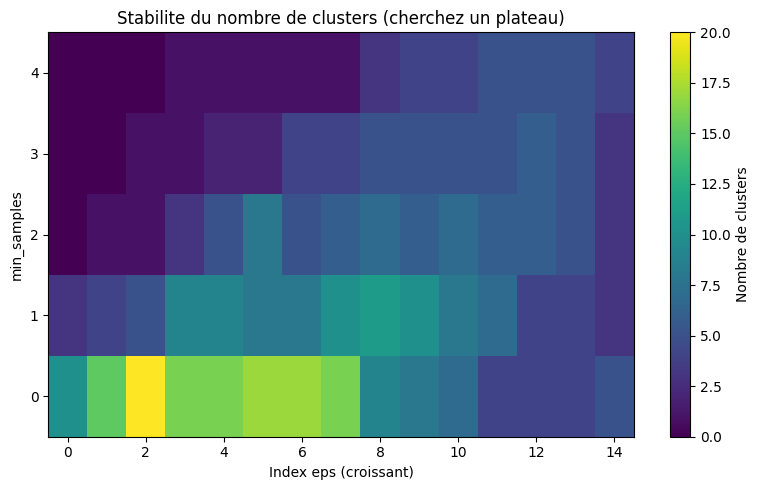

In [34]:
plot_cluster_stability(df_results)

In [ ]:
resultats = []

for region, (eps, min_samples) in params_par_region.items():
    df_r = df_communes[df_communes["region"] == nom_region].copy()
    X_r = df_r[["x", "y"]].values

    labels = DBSCAN(eps=eps, min_samples=min_samples, algorithm="kd_tree").fit_predict(X_r)

    df_r["cluster_local"] = labels
    df_r["cluster_global"] = df_r.apply(
        lambda row: f"{nom_region}_{row['cluster_local']}" if row["cluster_local"] != -1 else "noise",
        axis=1
    )

    resultats.append(df_r)

# DBSCAN et ENREGISTREMENT DES CLUSTERS

In [35]:
# Update de localisation avec les datatype geometry
ddl = [
    """
    ALTER TABLE cluster
    ALTER COLUMN cluster_id TYPE VARCHAR(50);
    """
]

with engine.begin() as conn:
    conn.execute(text("SET search_path TO incendies, public"))
    for stmt in ddl:
        conn.execute(text(stmt))
        conn.commit()

In [43]:
from datetime import date, datetime, timezone

# date experiment
date_experiment = datetime.now()

# type_cluster
with engine.connect() as conn:
    type_cluster = conn.execute(text("""
        SELECT id
        FROM type_cluster
        WHERE nom = 'complete'
    """)).scalar_one()

In [44]:
def db_scan(df, region, eps, min_samples):

    df_region = df.groupby("region").get_group(region).copy()
    X = df_region[["x", "y"]].values
    
    labels = DBSCAN(eps=eps, min_samples=min_samples)

    # fit_predict(X) fait deux choses d’un coup : il apprend les clusters sur X, 
    #  puis renvoie un tableau d’entiers, une valeur par ligne, dans le même ordre que df.
    #  Dès qu’il trouve un nouveau groupe dense, il lui donne le prochain entier : 0, puis 1, puis 2
    #  Il peut renvoyer -1 : point trop isolé
    clusters_locaux = labels.fit_predict(X)
    
    # ajustement des clusters locaux (-1 devient 0, les autres +1)
    df_region["cluster_local"] = np.where(
        clusters_locaux == -1, 0, clusters_locaux + 1
    )

    # Création du cluster global (ex: "17_1", "17_2")
    df_region["cluster_id"] = (
        df_region["region"].astype(str) + "_" + df_region["cluster_local"].astype(str)
    )
    
    return df_region

def update_cluster(df, date_experiment=date_experiment, type_cluster=type_cluster):

    df_copy = df.copy()
    
    # date experiment
    df_copy["date_experiment"] = date_experiment
    # type_cluster
    df_copy["type_cluster"] = type_cluster

    # colonnes de la table cluster
    df_insert = df_copy[["id_localisation", "date_experiment", "cluster_id", "type_cluster"]]

    sql = text("""
        INSERT INTO cluster (
            id_localisation, date_experiment, cluster_id, type_cluster
        )
        VALUES (
            :id_localisation, :date_experiment, :cluster_id, :type_cluster
        )
    """)

    with engine.begin() as conn:
        conn.execute(sql, df_insert.to_dict(orient="records"))

In [ ]:
# Rien pour les régions : Bourgogne-Franche-Comté, Hauts-de-France, Pays de la Loire

In [46]:
# Faible pour les régions : Île-de-France, Centre-Val de Loire, Normandie, Grand Est, Bretagne
df_scan = db_scan(df_communes, min_samples=4, eps=8000, region=6)
update_cluster(df_scan, date_experiment, type_cluster)
     
df_scan = db_scan(df_communes, min_samples=4, eps=8000, region=7)
update_cluster(df_scan, date_experiment, type_cluster)
     
df_scan = db_scan(df_communes, min_samples=4, eps=8000, region=9)
update_cluster(df_scan, date_experiment, type_cluster)
     
df_scan = db_scan(df_communes, min_samples=4, eps=8000, region=11)
update_cluster(df_scan, date_experiment, type_cluster)
     
df_scan = db_scan(df_communes, min_samples=4, eps=7571, region=13)
update_cluster(df_scan, date_experiment, type_cluster)


In [ ]:
# Bien pour les régions : Nouvelle-Aquitaine, Occitanie, Auvergne-Rhône-Alpes, Provence-Alpes-Côte d'Azur, Corse
df_scan = db_scan(df_communes, min_samples=4, eps=5428, region=14)
update_cluster(df_scan, date_experiment, type_cluster)
    
df_scan = db_scan(df_communes, min_samples=8, eps=7142, region=15)
update_cluster(df_scan, date_experiment, type_cluster)
    
df_scan = db_scan(df_communes, min_samples=8, eps=8000, region=16)
update_cluster(df_scan, date_experiment, type_cluster)
    
df_scan = db_scan(df_communes, min_samples=6, eps=6714, region=17)
update_cluster(df_scan, date_experiment, type_cluster)

df_scan = db_scan(df_communes, min_samples=12, eps=7571, region=18)
update_cluster(df_scan, date_experiment, type_cluster)

## Complete

In [8]:
# TOTAL COMMUNES
with engine.connect() as conn:
    df_communes = pd.read_sql(
        text("""
            SELECT 
                r.id as region,
                l.id_localisation,
                ST_X(l.geom_m) AS x,
                ST_Y(l.geom_m) AS y
            FROM localisation l
            JOIN commune c ON l.id_localisation = c.localisation
            JOIN departement d ON c.departement = d.code
            JOIN region r ON c.region = r.id
            WHERE 
                d.code NOT IN ('971', '972', '973', '974', '976')
                AND l.geom_m IS NOT NULL
            GROUP BY r.id, l.id_localisation
        """),conn)

if df_communes.empty:
    raise ValueError("aucun incendie à clusteriser")

print(df_communes[["x", "y"]].describe())


                  x             y
count  3.480100e+04  3.480100e+04
mean   6.855717e+05  6.653354e+06
std    2.015337e+05  2.475857e+05
min    1.022896e+05  6.051804e+06
25%    5.315064e+05  6.446423e+06
50%    6.792036e+05  6.700132e+06
75%    8.456766e+05  6.863153e+06
max    1.239135e+06  7.108481e+06


In [9]:
print(df_communes.duplicated(subset=["x", "y"]).sum())
print(df_communes.groupby(["x", "y"]).size().sort_values(ascending=False).head(10))

0
x              y           
102289.558940  6.847868e+06    1
787691.007615  6.528333e+06    1
788043.577508  6.749390e+06    1
787988.883258  6.841981e+06    1
787985.305831  6.661619e+06    1
787970.853426  6.976266e+06    1
787967.100062  6.924957e+06    1
787880.206067  6.568984e+06    1
787864.215524  6.941091e+06    1
787814.102945  6.719386e+06    1
dtype: int64


In [16]:
resultats = {}

for region, df_region in df_communes.groupby("region"):

    if(region == 6):
        print(f"---- {region} ----")

        X = df_region[["x", "y"]].values

        # Suggest Epsilon
        eps_values = suggest_eps_range(X, k=4, n_points=15)



---- 6 ----


In [17]:
eps_values

array([3450.9259505 , 3549.13298825, 3647.34002599, 3745.54706374,
       3843.75410148, 3941.96113923, 4040.16817697, 4138.37521471,
       4236.58225246, 4334.7892902 , 4432.99632795, 4531.20336569,
       4629.41040344, 4727.61744118, 4825.82447893])

In [ ]:
# Grid Search
eps_values = np.linspace(2000, 8000, 15)
min_samples_values = [4, 6, 8, 10, 12]
df_results = dbscan_grid_search(X, eps_values, min_samples_values) 

best = select_best_params(df_results, max_noise_ratio=0.35)
if best is not None:
    top = best.iloc[0]
    best_eps = top["eps"]
    best_min_samples = int(top["min_samples"])

    # print("Meilleure combinaison trouvee :")
    # print(f"  eps          = {top['eps']:.0f} m")
    # print(f"  min_samples  = {top['min_samples']}")
    # print(f"  n_clusters   = {top['n_clusters']}")
    # print(f"  noise_ratio  = {top['noise_ratio']}")
    # print(f"  silhouette   = {top['silhouette']:.4f}")
    # print(f"  davies_bouldin = {top['davies_bouldin']:.4f}")

    print(best.head(10).to_string(index=False))
    df_results, best = find_best(df_region,X)

    print("\n")

    resultats[region] = best